In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("data/student_product_engagement.csv")

df.head()

,session_id,product_id,watch_duration
0,b5df2541-1c1d-4b1b-82ce-a7400a086f45,P0039,52.31
1,0a51720d-727e-4586-98c8-295f712912d5,P0272,37.06
2,cc352f23-61cf-4f7d-a9a3-e1f94e8f5374,P0253,14.66
3,a796560a-6e19-4633-92df-33bd6f154366,P0063,20.74
4,96370e9b-72fb-47cd-9e75-ecb58e202405,P0072,3.68


In [3]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   session_id      20000 non-null  str    
 1   product_id      20000 non-null  str    
 2   watch_duration  20000 non-null  float64
dtypes: float64(1), str(2)
memory usage: 468.9 KB


,watch_duration
count,20000.000000
mean,39.930613
std,39.883717
min,0.000000
25%,11.470000
50%,27.520000
75%,55.282500
max,300.000000


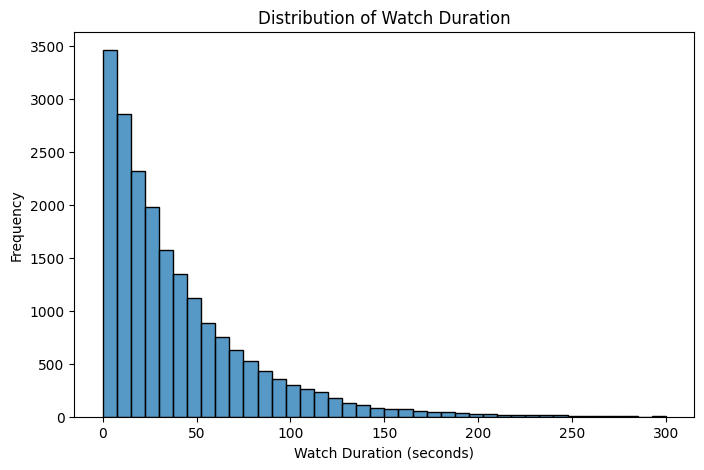

In [4]:
plt.figure(figsize=(8,5))
sns.histplot(df["watch_duration"], bins=40)
plt.title("Distribution of Watch Duration")
plt.xlabel("Watch Duration (seconds)")
plt.ylabel("Frequency")
plt.show()

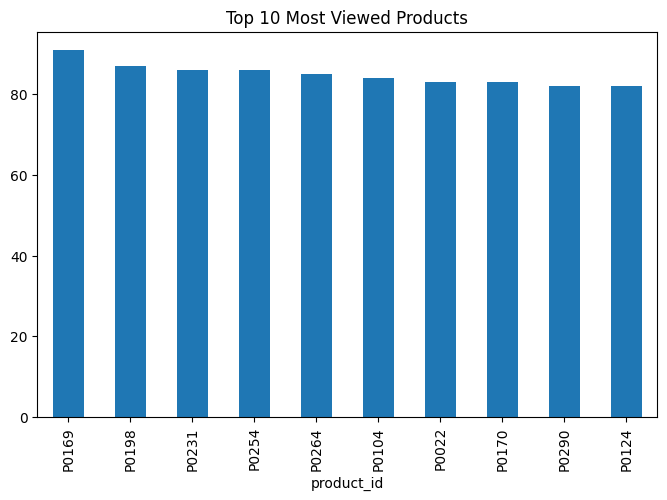

In [5]:
top_products = df["product_id"].value_counts().head(10)

plt.figure(figsize=(8,5))
top_products.plot(kind="bar")
plt.title("Top 10 Most Viewed Products")
plt.show()

In [6]:
product_features = df.groupby("product_id").agg({
    "watch_duration": ["sum", "mean", "count"]
}).reset_index()

product_features.columns = [
    "product_id",
    "total_watch_time",
    "avg_watch_time",
    "view_count"
]

product_features.head()

,product_id,total_watch_time,avg_watch_time,view_count
0,P0001,2648.27,38.945147,68
1,P0002,2599.21,49.984808,52
2,P0003,1919.97,31.474918,61
3,P0004,2423.86,43.283214,56
4,P0005,2921.04,37.935584,77


In [7]:
scaler = MinMaxScaler()

scaled_values = scaler.fit_transform(
    product_features[["total_watch_time", "avg_watch_time", "view_count"]]
)

scaled_df = pd.DataFrame(
    scaled_values,
    columns=["total_scaled", "avg_scaled", "count_scaled"]
)

product_features = pd.concat([product_features, scaled_df], axis=1)

In [8]:
product_features["engagement_score"] = (
    0.4 * product_features["avg_scaled"] +
    0.3 * product_features["count_scaled"] +
    0.3 * product_features["total_scaled"]
)

In [9]:
product_features = product_features.sort_values(
    "engagement_score",
    ascending=False
)

product_features["rank"] = range(1, len(product_features)+1)

product_features.head(10)

,product_id,total_watch_time,avg_watch_time,view_count,total_scaled,avg_scaled,count_scaled,engagement_score,rank
299,P0300,3989.14,49.248642,81,1.000000,0.779410,0.791667,0.849264,1
27,P0028,3903.63,52.048400,75,0.966631,0.880167,0.666667,0.842056,2
183,P0184,3818.58,52.309315,73,0.933441,0.889557,0.625000,0.823355,3
297,P0298,3885.06,48.563250,80,0.959384,0.754744,0.770833,0.820963,4
168,P0169,3928.44,43.169670,91,0.976312,0.560640,1.000000,0.817150,5
232,P0233,3761.19,46.434444,81,0.911045,0.678132,0.791667,0.782066,6
166,P0167,3721.54,46.519250,80,0.895572,0.681184,0.770833,0.772395,7
241,P0242,3527.39,51.873382,68,0.819806,0.873869,0.520833,0.751739,8
70,P0071,3610.17,45.698354,79,0.852110,0.651642,0.750000,0.741290,9
36,P0037,3378.07,55.378197,61,0.761536,1.000000,0.375000,0.740961,10


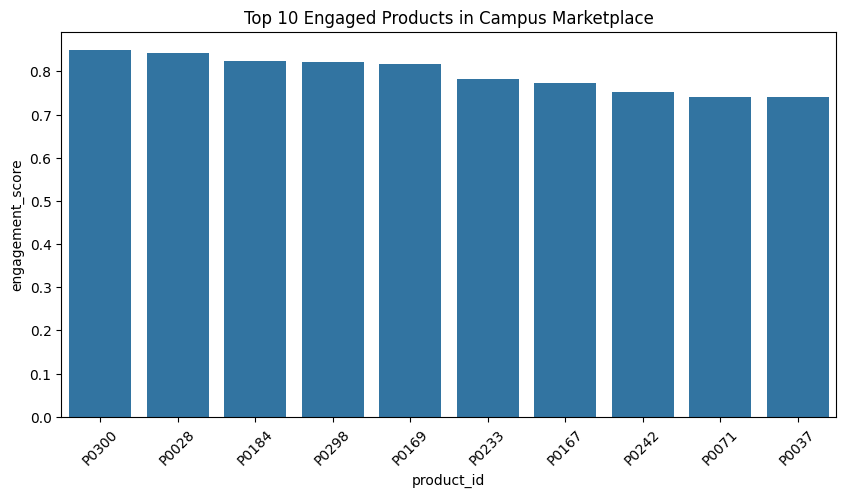

In [10]:
top10 = product_features.head(10)

plt.figure(figsize=(10,5))
sns.barplot(
    x="product_id",
    y="engagement_score",
    data=top10
)
plt.title("Top 10 Engaged Products in Campus Marketplace")
plt.xticks(rotation=45)
plt.show()

In [11]:
kmeans = KMeans(n_clusters=3, random_state=42)

cluster_features = product_features[
    ["total_scaled", "avg_scaled", "count_scaled"]
]

product_features["cluster"] = kmeans.fit_predict(cluster_features)

In [12]:
cluster_summary = product_features.groupby("cluster")[
    "engagement_score"
].mean()

cluster_summary

cluster
0    0.527726
1    0.336662
2    0.610282
Name: engagement_score, dtype: float64

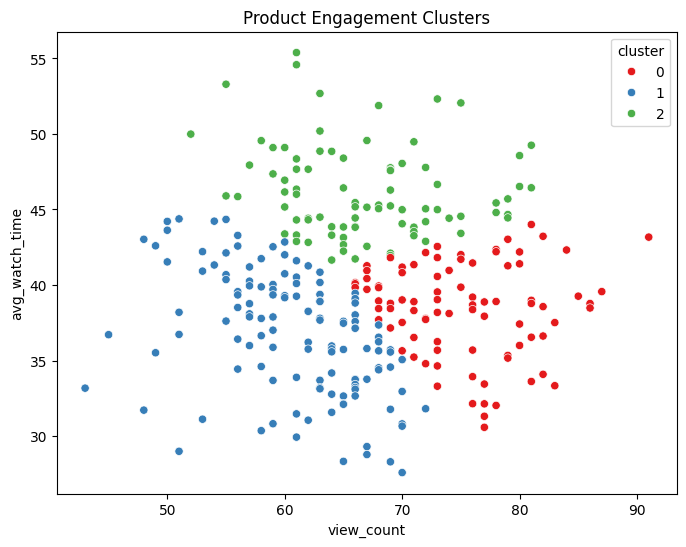

In [13]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x="view_count",
    y="avg_watch_time",
    hue="cluster",
    data=product_features,
    palette="Set1"
)
plt.title("Product Engagement Clusters")
plt.show()

In [15]:
product_features.to_csv(
    "outputs/engagement_ranking.csv",
    index=False
)

print("Engagement ranking saved successfully!")

Engagement ranking saved successfully!
